micro:bit code: https://makecode.microbit.org/S86676-82786-95363-22138


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupShuffleSplit, GridSearchCV
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight
import joblib

In [2]:
f = [('b',4),('dp',6),('s',4)]
filenames = []

for prefix,n in f:
    for i in range(1,n+1):
        filenames.append(f'{prefix}{i}.csv')

print(filenames)


['b1.csv', 'b2.csv', 'b3.csv', 'b4.csv', 'dp1.csv', 'dp2.csv', 'dp3.csv', 'dp4.csv', 'dp5.csv', 'dp6.csv', 's1.csv', 's2.csv', 's3.csv', 's4.csv']


In [3]:
required_columns = ['time', 'strength', 'label']
all_dfs = []

for filename in filenames:
    df = pd.read_csv('labeled data/'+filename)

    # Rename column 'Time (seconds)' -> 'time'
    if 'Time (seconds)' in df.columns:
        df.rename(columns={'Time (seconds)': 'time'}, inplace=True)

    # Check for the presence of 'time', 'strength', and 'label' columns
    missing_columns = [col for col in required_columns if col not in df.columns]

    df['file'] = filename

    df.dropna(inplace=True)
    all_dfs.append(df)

df = pd.concat(all_dfs, ignore_index=True)

if not missing_columns:
    print(f"All required columns {required_columns} are present in the DataFrame.")
else:
    print(f"Warning: The following required columns are missing from the DataFrame: {missing_columns}")

All required columns ['time', 'strength', 'label'] are present in the DataFrame.


In [4]:
df.head()

,time,strength,label,file
0,9.39,998,bump,b1.csv
1,9.49,990,bump,b1.csv
2,9.59,990,bump,b1.csv
3,9.69,1283,bump,b1.csv
4,9.79,906,bump,b1.csv


# Data Preprocessing

In [5]:
# PARAMETERS
WINDOW_SIZE = 7
THRESHOLD_SEC = 1.5

In [6]:
def process_labeled_data(df, threshold_sec=THRESHOLD_SEC, window_size=WINDOW_SIZE):
    """
    df: Combined DataFrame with columns ['time', 'strength', 'label', 'file']
    """
    all_features = []

    # 1. Group by filename first to ensure we never mix data from different files
    for filename, file_group in df.groupby('file'):

        # 2. Identify 'leaps' within this specific file
        # We work on a copy to avoid SettingWithCopy warnings
        temp_df = file_group.copy().sort_values('time')
        temp_df['time_diff'] = temp_df['time'].diff()

        # Mark sessions: triggered by time gaps OR time resets (negative diff)
        temp_df['session_id'] = ((temp_df['time_diff'] > threshold_sec) | (temp_df['time_diff'] < 0)).cumsum()

        # 3. Iterate through each continuous session in this file
        for session_id, session_group in temp_df.groupby('session_id'):
            if len(session_group) < window_size:
                continue

            # 4. Slide the window
            step = window_size // 2
            for i in range(0, len(session_group) - window_size + 1, step):
                window = session_group.iloc[i : i + window_size]

                # --- THE "PURE WINDOW" RULE ---
                current_labels = window['label'].dropna().unique()

                # Logic: Only process if all {WINDOW_SIZE} samples have EXACTLY one label
                # and there are no NaNs in the window
                if len(current_labels) == 1 and not window['label'].isnull().any():
                    win_label = current_labels[0]

                    # Normalize strength (1000 = 1.0g)
                    strength_values = window['strength'].values / 1000.0

                    # --- FEATURE EXTRACTION ---
                    features = {
                        'mean': np.mean(strength_values),
                        'std':  np.std(strength_values),
                        'max':  np.max(strength_values),
                        'min':  np.min(strength_values),
                        'p2p':  np.ptp(strength_values),
                        'zcr':  np.sum(np.diff(strength_values > 1.0) != 0),
                        'max_abs_diff': np.max(np.abs(np.diff(strength_values))),
                        'initial_delta': strength_values[2] - strength_values[0],
                        'label': win_label,
                        'file': filename,
                        'session_id': session_id
                    }
                    all_features.append(features)

    return pd.DataFrame(all_features)

In [7]:
feature_matrix = process_labeled_data(df)

In [8]:
display(feature_matrix.head())

,mean,std,max,min,p2p,zcr,max_abs_diff,initial_delta,label,file,session_id
0,0.971857,0.175399,1.283,0.637,0.646,2,0.377,-0.008,bump,b1.csv,0
1,1.087429,0.166069,1.460,0.950,0.510,2,0.469,-0.001,bump,b1.csv,1
2,1.086286,0.166748,1.460,0.950,0.510,1,0.408,-0.288,bump,b1.csv,1
3,1.237429,0.387223,2.149,0.989,1.160,1,1.160,-0.007,bump,b1.csv,2
4,1.237143,0.387421,2.149,0.984,1.165,1,0.868,-0.943,bump,b1.csv,2


In [63]:
display(feature_matrix.groupby('label').size())

label
bump       153
drop       139
pickup     206
still     2275
dtype: int64

In [64]:
feature_matrix.to_csv('move_train_data1.csv')

# Visualisation

In [30]:
def plot_feature_clusters(feature_df, label_column='label'):
    """
    feature_df: The DataFrame containing your engineered features and a 'label' column.
    """
    # 1. Separate features and labels
    features = feature_df.drop(columns=[label_column, 'session_id'], errors='ignore')
    labels = feature_df[label_column]

    # 2. Standardize the data (very important for PCA)
    x = StandardScaler().fit_transform(features)

    # 3. Perform PCA (Reduce to 2 Dimensions)
    pca = PCA(n_components=2)
    components = pca.fit_transform(x)

    # 4. Create a plot DataFrame
    plot_df = pd.DataFrame(data=components, columns=['PC1', 'PC2'])
    plot_df['label'] = labels.values

    # 5. Visualize
    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='label', style='label', s=100)
    plt.title("Movement Classification Clusters (PCA)")
    plt.show()

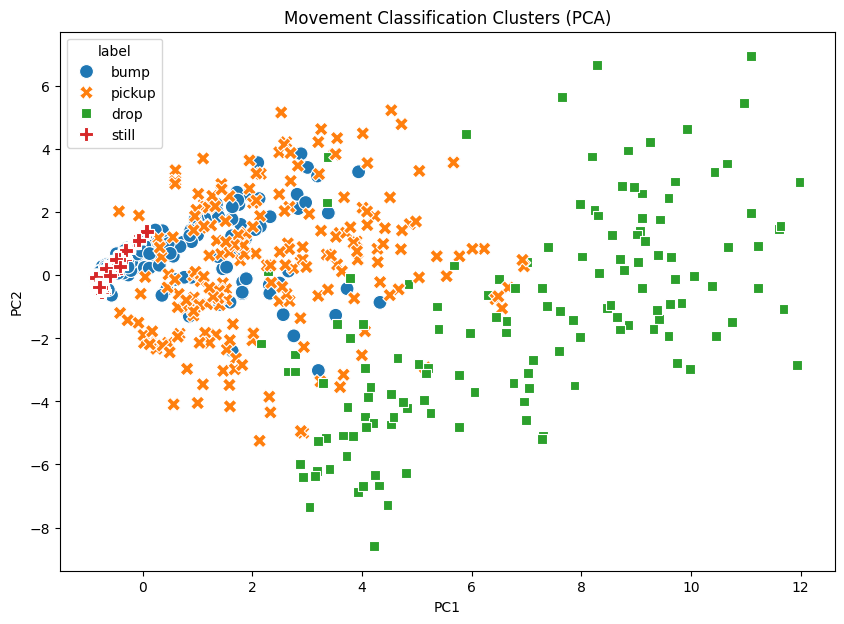

In [31]:
plot_feature_clusters(feature_matrix, label_column='label')

In [36]:
def plot_feature_clusters_3d(feature_df, label_column='label'):
    # 1. Prepare Data
    # Drop non-feature columns
    features = feature_df.drop(columns=[label_column, 'file_source', 'session_id'], errors='ignore')
    labels = feature_df[label_column]

    # 2. Standardize
    x = StandardScaler().fit_transform(features)

    # 3. PCA for 3 Components
    pca = PCA(n_components=3)
    components = pca.fit_transform(x)

    # Print the "Value" of the 3rd dimension
    variance = pca.explained_variance_ratio_
    print(f"Variance explained: PC1={variance[0]:.2f}, PC2={variance[1]:.2f}, PC3={variance[2]:.2f}")
    print(f"Total variance captured: {sum(variance):.2f}")

    # 4. Create Plotting DataFrame
    plot_df = pd.DataFrame(data=components, columns=['PC1', 'PC2', 'PC3'])
    plot_df['label'] = labels.values

    # 5. Visualize in 3D
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    for label in feature_df['label'].unique():
          mask = feature_df['label'] == label
          ax.scatter(components[mask, 0],
                    components[mask, 1],
                    components[mask, 2],
                    label=label,   # This creates the legend entry
                    s=60,
                    alpha=0.7)

    plt.title("3D PCA")
    plt.legend()
    plt.show()

Variance explained: PC1=0.65, PC2=0.20, PC3=0.13
Total variance captured: 0.99


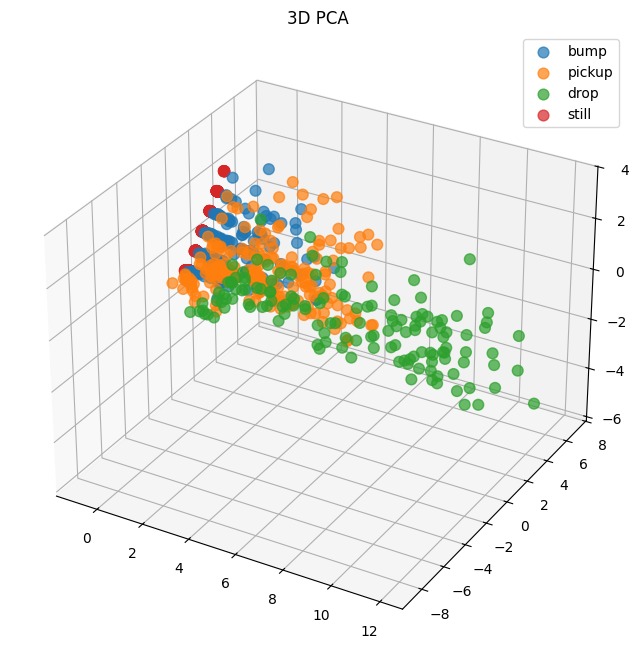

In [37]:
plot_feature_clusters_3d(feature_matrix, label_column='label')

In [119]:
features_df=feature_matrix.copy()
features_df

,mean,std,max,min,p2p,zcr,max_abs_diff,initial_delta,label,file,session_id
0,0.971857,0.175399,1.283,0.637,0.646,2,0.377,-0.008,bump,b1.csv,0
1,1.087429,0.166069,1.460,0.950,0.510,2,0.469,-0.001,bump,b1.csv,1
2,1.086286,0.166748,1.460,0.950,0.510,1,0.408,-0.288,bump,b1.csv,1
3,1.237429,0.387223,2.149,0.989,1.160,1,1.160,-0.007,bump,b1.csv,2
4,1.237143,0.387421,2.149,0.984,1.165,1,0.868,-0.943,bump,b1.csv,2
...,...,...,...,...,...,...,...,...,...,...,...
2768,0.987000,0.003742,0.994,0.981,0.013,0,0.008,0.005,still,s4.csv,0
2769,0.987143,0.004086,0.994,0.981,0.013,0,0.008,-0.007,still,s4.csv,0
2770,0.985714,0.006341,0.996,0.975,0.021,0,0.021,-0.004,still,s4.csv,0
2771,0.985000,0.006481,0.996,0.975,0.021,0,0.021,0.005,still,s4.csv,0


In [45]:
features_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2773 entries, 0 to 2772
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   mean           2773 non-null   float64
 1   std            2773 non-null   float64
 2   max            2773 non-null   float64
 3   min            2773 non-null   float64
 4   p2p            2773 non-null   float64
 5   zcr            2773 non-null   int32  
 6   max_abs_diff   2773 non-null   float64
 7   initial_delta  2773 non-null   float64
 8   label          2773 non-null   object 
dtypes: float64(7), int32(1), object(1)
memory usage: 184.3+ KB


In [ ]:
feature_cols = ['mean', 'std', 'max', 'min', 'p2p', 'zcr', 'max_abs_diff','initial_delta']
target_col = 'label'
group_col = 'file'

X = features_df[feature_cols].copy()
y = features_df[target_col].copy()

if group_col in features_df.columns:
    groups = features_df[group_col].copy()
else:
    groups = None
    print("Warning: 'file' column not found. Will fall back to random split, which is less reliable.")

In [69]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", list(label_encoder.classes_))

Classes: ['bump', 'drop', 'pickup', 'still']


In [122]:
if groups is not None:
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups=groups))
else:
    from sklearn.model_selection import train_test_split
    train_idx, test_idx = train_test_split(
        np.arange(len(X)),
        test_size=0.2,
        random_state=42,
        stratify=y
    )

X_train = X.iloc[train_idx].reset_index(drop=True)
X_test = X.iloc[test_idx].reset_index(drop=True)

y_train = y[train_idx]
y_test = y[test_idx]

if groups is not None:
    groups_train = groups.iloc[train_idx].reset_index(drop=True)
else:
    groups_train = None

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain label distribution:")
print(y_train.value_counts())

print("\nTest label distribution:")
print(y_test.value_counts())

Train shape: (1525, 8)
Test shape: (1248, 8)

Train label distribution:
label
still     1074
pickup     186
bump       137
drop       128
Name: count, dtype: int64

Test label distribution:
label
still     1201
pickup      20
bump        16
drop        11
Name: count, dtype: int64


In [75]:
classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight_dict = {cls: w for cls, w in zip(classes, class_weights)}
print("Class weight dict:", class_weight_dict)

for cls_id, w in class_weight_dict.items():
    print(label_encoder.inverse_transform([cls_id])[0], "->", w)

Class weight dict: {0: 2.7828467153284673, 1: 2.978515625, 2: 2.049731182795699, 3: 0.35498137802607077}
bump -> 2.7828467153284673
drop -> 2.978515625
pickup -> 2.049731182795699
still -> 0.35498137802607077


In [123]:
rf_baseline = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_baseline.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [124]:
y_train_pred = rf_baseline.predict(X_train)
y_test_pred = rf_baseline.predict(X_test)
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

train_f1_macro = f1_score(y_train, y_train_pred, average='macro')
test_f1_macro = f1_score(y_test, y_test_pred, average='macro')

train_f1_weighted = f1_score(y_train, y_train_pred, average='weighted')
test_f1_weighted = f1_score(y_test, y_test_pred, average='weighted')

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

print("\nTrain Macro-F1:", train_f1_macro)
print("Test Macro-F1:", test_f1_macro)

print("\nTrain Weighted-F1:", train_f1_weighted)
print("Test Weighted-F1:", test_f1_weighted)

Train Accuracy: 1.0
Test Accuracy: 0.9927884615384616

Train Macro-F1: 1.0
Test Macro-F1: 0.8621276595744681

Train Weighted-F1: 1.0
Test Weighted-F1: 0.9923158756137479


In [125]:
print(classification_report(y_test, y_test_pred, digits=4))

              precision    recall  f1-score   support

        bump     0.8889    0.5000    0.6400        16
        drop     1.0000    1.0000    1.0000        11
      pickup     0.7037    0.9500    0.8085        20
       still     1.0000    1.0000    1.0000      1201

    accuracy                         0.9928      1248
   macro avg     0.8981    0.8625    0.8621      1248
weighted avg     0.9938    0.9928    0.9923      1248



In [141]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_baseline.fit(X_train, y_train)
y_pred_baseline = rf_baseline.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, y_pred_baseline))
print("Baseline Macro-F1:", f1_score(y_test, y_pred_baseline, average='macro'))
print("Baseline Weighted-F1:", f1_score(y_test, y_pred_baseline, average='weighted'))

Baseline Accuracy: 0.9927884615384616
Baseline Macro-F1: 0.8621276595744681
Baseline Weighted-F1: 0.9923158756137479


In [145]:
print(classification_report(y_test, y_pred_baseline, digits=4))

              precision    recall  f1-score   support

        bump     0.8889    0.5000    0.6400        16
        drop     1.0000    1.0000    1.0000        11
      pickup     0.7037    0.9500    0.8085        20
       still     1.0000    1.0000    1.0000      1201

    accuracy                         0.9928      1248
   macro avg     0.8981    0.8625    0.8621      1248
weighted avg     0.9938    0.9928    0.9923      1248



In [128]:
if groups_train is not None:
    cv_strategy = GroupKFold(n_splits=5)
    cv_groups = groups_train
else:
    cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_groups = None

In [ ]:
'''param_grid_rf = {
    'n_estimators': [200, 300, 500],
    'max_features': ['sqrt', 'log2', None],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5],
    'class_weight': [ 'balanced', 'balanced_subsample']
}
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    scoring='f1_macro',
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1,
    refit=True
)'''

In [ ]:
'''if cv_groups is not None:
    grid_rf.fit(X_train, y_train, groups=cv_groups)
else:
    grid_rf.fit(X_train, y_train)'''

Fitting 5 folds for each of 108 candidates, totalling 540 fits


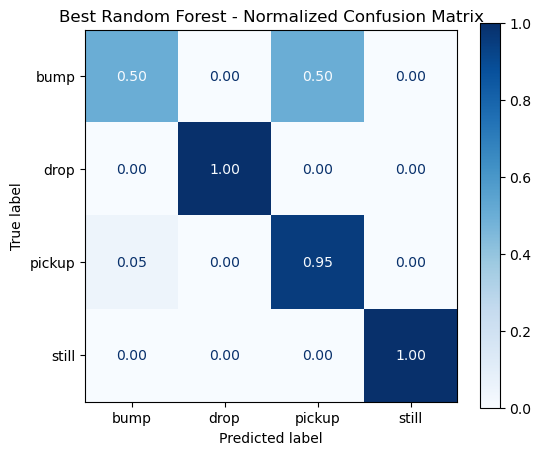

In [146]:
cm_norm = confusion_matrix(y_test,y_pred_baseline, normalize='true')

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=rf_baseline.classes_
)
disp.plot(ax=ax, cmap='Blues', values_format='.2f')
plt.title("Best Random Forest - Normalized Confusion Matrix")
plt.show()

In [147]:
feat_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance':rf_baseline.feature_importances_
}).sort_values('importance', ascending=False)

print(feat_imp)

         feature  importance
1            std    0.207942
3            min    0.189424
5   max_abs_diff    0.168760
4            p2p    0.168531
2            max    0.105957
0           mean    0.085078
6  initial_delta    0.041259
7            zcr    0.033049


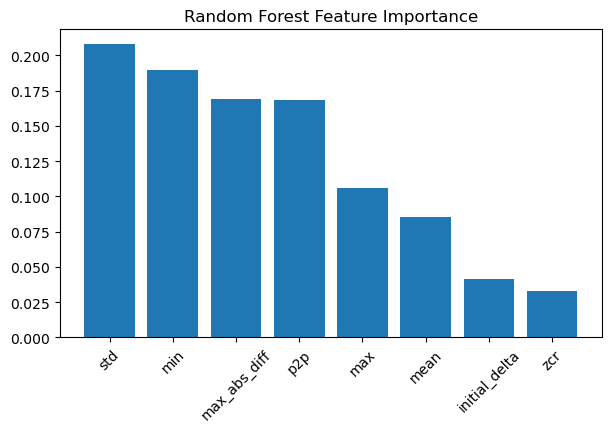

In [148]:
plt.figure(figsize=(7, 4))
plt.bar(feat_imp['feature'], feat_imp['importance'])
plt.title("Random Forest Feature Importance")
plt.xticks(rotation=45)
plt.show()

In [ ]:


model_bundle = {
    'model': rf_baseline,          
    'feature_cols': feature_cols, 
    'class_names': sorted(y_train.unique()) if hasattr(y_train, 'unique') else None
}

joblib.dump(model_bundle, 'rf_baseline_bundle.pkl')
print("Model saved successfully.")

Model saved successfully.


In [3]:
bundle = joblib.load('rf_baseline_bundle.pkl')

loaded_model = bundle['model']
feature_cols = bundle['feature_cols']
class_names = bundle.get('class_names', None)

print("Loaded feature columns:", feature_cols)
print("Loaded class names:", class_names)


Loaded feature columns: ['mean', 'std', 'max', 'min', 'p2p', 'zcr', 'max_abs_diff', 'initial_delta']
Loaded class names: ['bump', 'drop', 'pickup', 'still']


In [4]:
new_df = pd.DataFrame([
    {'mean': 1.02, 'std': 0.08, 'max': 1.25, 'min': 0.95, 'p2p': 0.30, 'zcr': 2, 'max_abs_diff':1,'initial_delta':0.5},
    {'mean': 0.98, 'std': 0.03, 'max': 1.05, 'min': 0.93, 'p2p': 0.12, 'zcr': 1, 'max_abs_diff':1.2,'initial_delta':0.4}
])
X_new = new_df[feature_cols]
preds = loaded_model.predict(X_new)

print(preds)

['bump' 'bump']
